# Глава 8. Проблемы точности и галлюцинаций

## 8.1. Типичные проблемы RAG‑систем

**Галлюцинации в RAG — критическая проблема.** Хотя RAG создавали для борьбы с ошибками больших языковых моделей, при плохой реализации он может их усугублять. Даже с точным контекстом достоверность ответов не превышает 80%. Проблема системная и требует комплексного подхода.

### Проблемы поискового компонента
- **Низкое качество:** векторный поиск находит нужный фрагмент лишь в 30% случаев.
- **«Потерянное посередине»:** модель игнорирует важные факты в середине длинного контекста, фокусируясь на начале и конце.
- **Несоответствие плотности знаний:** по запросу извлекается много повторяющейся информации.
- **Семантический разрыв:** технические термины извлекаются формально, а не по смыслу.

### Проблемы качества данных

- **Мусор на входе — мусор на выходе.** Неточные, устаревшие или неструктурированные данные в базе делают бесполезными даже идеальные алгоритмы.
- **Устаревание.** Без обновления базы RAG сам становится источником устаревшей информации, для борьбы с которой его и создавали.
- **Дублирование и противоречия.** Разные версии документов в базе ведут к противоречивым ответам.
- **Плохая структура.** Отсутствие заголовков и метаданных усложняет поиск и снижает его качество.

### Проблемы стратегии сегментирования

-   **Размер имеет значение.**
    -   Маленькие чанки теряют контекст.
    -   Большие — содержат шум, запутывающий модель.
-   **Потеря связей.** Логически единая информация физически разрывается на разные чанки и интерпретируется неверно.
-   **Разрушение структуры.** Стандартные методы ломают таблицы и схемы, делая их бесполезными.

### Проблемы генеративного компонента

-   **Неверная интерпретация.** Модель ошибается в связях и выводах, даже получив правильный контекст.
-   **Выдумка при нехватке данных.** Вместо честного «я не знаю» генерирует правдоподобную ложь.
-   **Конфликт знаний.** Внутренние данные модели противоречат извлеченному контексту, что ведет к хаосу в ответах.
-   **Неумение отказываться.** Модель почти никогда не признает незнание, делая выводы из косвенных данных или догадок.

### Архитектурные проблемы

-   **Высокая задержка.** Многоступенчатый пайплайн тормозит ответ, ограничивая интерактивное применение.
-   **Сложное масштабирование.** С ростом базы знаний сохранять скорость поиска всё труднее.
-   **Кратный рост стоимости.** Каждый дополнительный фрагмент в промпте увеличивает цену запроса к модели.

### Проблемы оценки и мониторинга

-   **Комплексность.** Недостаточно оценить только итоговый ответ. Нужно проверять отдельно релевантность поиска и точность следования контексту.
-   **Отсутствие стандартов.** Разные исследования используют свои метрики, что не дает объективно сравнивать системы между собой.
-   **Трудность диагностики.** В многокомпонентной системе сложно найти корень ошибки: виноват поиск, обработка или генерация.

### Проблемы предметной специфичности

-   **Усиление предвзятости.** RAG тиражирует искажения, уже заложенные в исходных данных.
-   **Нечеткие запросы.** Сленг и обрывки фраз от реальных пользователей сложно перевести в нормальный поиск.
-   **Мультиязычность.** Трудно обеспечить одинаковое качество поиска и ответов на разных языках.

**Вывод:** Проблемы RAG носят комплексный характер. Точечные правки не работают — улучшать нужно всю цепочку одновременно. Понимание этих узких мест — первый шаг к созданию надежной системы.

## 8.2. Методы борьбы с галлюцинациями

Полностью убрать галлюцинации в RAG-системах нельзя, но можно сильно снизить их частоту и влияние. Для этого применяют комплекс методов из машинного обучения, промпт-инженерии, архитектуры и когнитивных наук.

Борьба с галлюцинациями идёт на всех этапах работы системы — от подготовки данных до финальной обработки результатов. Каждый метод нацелен на конкретную причину галлюцинаций и требует своей реализации.

### Архитектурные методы снижения галлюцинаций

**Качество извлечения информации** — первый барьер против галлюцинаций:
- **Гибридный поиск** сочетает семантический и лексический подходы для точного отбора релевантных фрагментов.
- **Переранжирование** с кросс-энкодерами дополнительно фильтрует результаты.

**Контроль контекстного окна** предотвращает перегрузку модели:
- **Сжатие контекста** убирает лишнее, оставляя ключевые факты.
- **Важные данные размещают в начале и конце** — так работают механизмы внимания моделей.

**Обнаружение противоречий** выявляет проблемные места:
- Алгоритмы сравнивают утверждения из разных источников и предупреждают о конфликтах.

**Множественная проверка** основана на консенсусе источников:
- Система запрашивает данные из нескольких независимых баз и находит расхождения.

### Техники промпт‑инженерии

- **Явные инструкции** — фразы вроде «Отвечай только на основе предоставленной информации» или «Если данных нет, скажи "Я не знаю"» направляют модель к осторожности.
- **Chain‑of‑Thought** — пошаговое рассуждение делает генерацию прозрачнее и помогает заметить момент отхода от фактов.
- **Самокритика и рефлексия** — модель сама оценивает уверенность в ответе и сверяет его с контекстом.
- **Few‑Shot с примерами** — тщательно подобранные примеры учат модель правильно реагировать на неопределённость, включая признание неведения.

### Алгоритмические подходы

- **Self-Consistency** — система генерирует несколько вариантов ответа и выбирает самый частый. Галлюцинации обычно не повторяются.
- **Beam search с кастомным скорингом** — учитывает не только языковую вероятность, но и соответствие контексту.
- **Контрастивное обучение** — модель учится различать правдивые и ложные утверждения на специальных парах примеров.
- **Калибровка уверенности** — настройка соответствия между внутренней уверенностью модели и реальной точностью ответов.

### Методы обучения и дообучения

- **RLHF** — донастройка модели на основе оценок достоверности ответов операторами-аннотаторами.
- **Дообучение на проверенных данных** — датасеты тщательно чистятся на точность и актуальность.
- **Регуляризация** — dropout и label smoothing защищают модель от переобучения на зашумлённых данных.
- **Adversarial training** — обучение на примерах, специально созданных для провоцирования галлюцинаций.

### Постпроцессинговые методы

- **Верификация фактов** — внешние базы знаний или спецмодели проверяют утверждения в реальном времени.
- **Обнаружение галлюцинаций** — анализ энтропии, паттернов активации и других внутренних сигналов модели выявляет проблемные генерации.
- **Цитирование и атрибуция** — модель обязана указывать источники для каждого утверждения, что повышает прозрачность.
- **Фильтрация и guardrails** — множественные проверки блокируют неточные ответы до показа пользователю.

### Интегрированные подходы

- **Многоагентные системы** — разные агенты отвечают за поиск, проверку консистентности и генерацию.
- **Обучение говорить «Я не знаю»** — модель тренируют признавать неведение на специальных датасетах с вопросами без ответа.
- **Динамическая температура** — при неуверенности система снижает «творческий режим» и выдаёт более консервативные ответы.
- **Итеративное уточнение** — ответ улучшается за несколько циклов поиска и генерации с обратной связью.
- **Гибридные архитектуры** — комбинация улучшенного поиска, промптов, постобработки и обратной связи от людей создаёт многоуровневую защиту.

**Итог**: одного метода недостаточно. Только системный подход, объединяющий техники на всех уровнях, даёт значительно более надёжные RAG-системы.

## 8.3. Гарды и системы контроля

Гарды — это многоуровневая система защиты RAG на всех этапах обработки запросов. Они сочетают правила, машинное обучение и архитектурные паттерны для комплексной защиты от рисков.

Защита в глубину координирует работу множества уровней, каждый из которых нацелен на свои типы угроз: от входной валидации до финального аудита результатов.

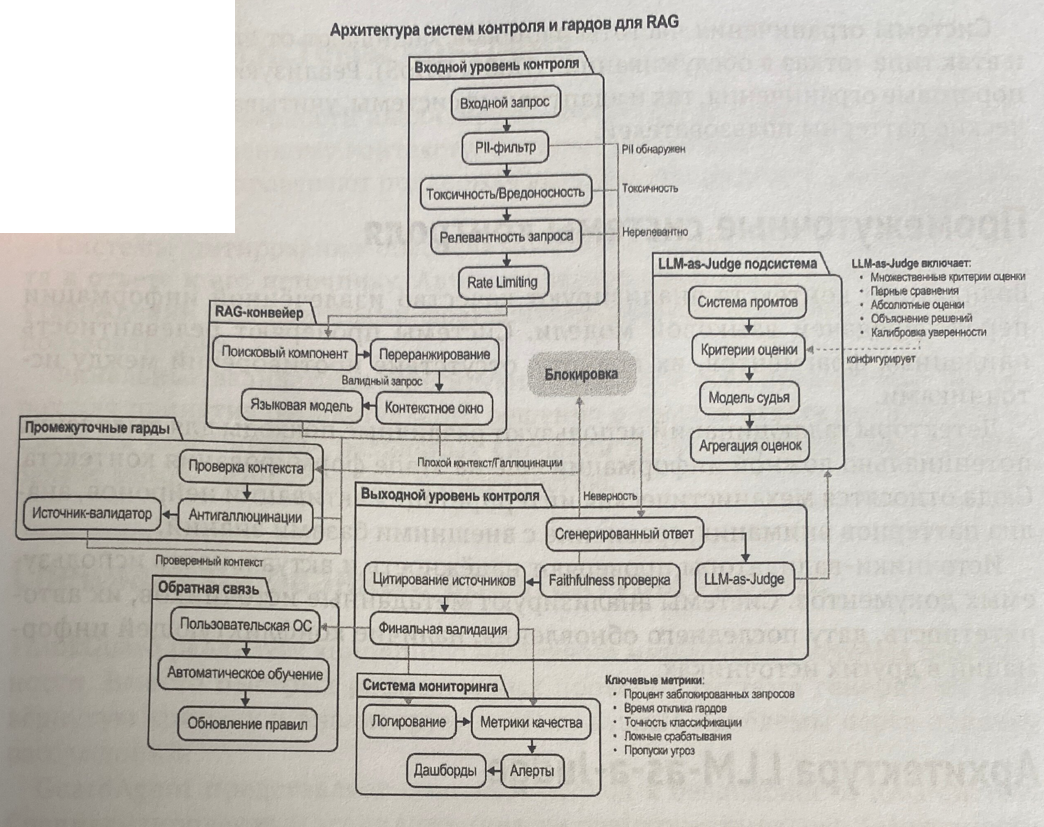

### Входные гарды и валидация

**Классификаторы релевантности** — первая линия защиты от нецелевых запросов. Определяют, входит ли запрос в компетенцию RAG-системы, используя методы машинного обучения и эмбеддинг-модели.

**PII-фильтры** выявляют персональные данные в запросах. Сочетают регулярные выражения, NER и специализированные модели для обнаружения телефонов, email, номеров соцстрахования и других чувствительных данных.

**Детекторы токсичности** блокируют неподходящие запросы. Многоклассовые модели различают типы проблемного контента: ненависть, угрозы, домогательства, самоповреждение, сексуальный контент.

**Ограничители частоты запросов** защищают от злоупотреблений и DoS/DDoS-атак. Реализуются через пороговые ограничения и адаптивные системы, учитывающие поведение пользователей.

### Промежуточные системы контроля

**Валидаторы контекста** проверяют качество извлечённой информации перед подачей в модель: релевантность фрагментов, их полноту и отсутствие противоречий между источниками.

**Детекторы галлюцинаций** выявляют потенциально ложную информацию на этапе формирования контекста. Подходы: механистическая интерпретация нейронов, анализ паттернов внимания, сравнение с внешними базами знаний.

**Валидаторы источников** проверяют надёжность документов: метаданные, авторитетность, дату обновления, наличие конфликтующей информации в других источниках.

### Архитектура LLM‑as‑a‑Judge

**LLM-as-a-Judge** — парадигмальный сдвиг в автооценке качества текстов. Вместо жёстких правил языковые модели имитируют человеческие суждения о качестве, безопасности и релевантности контента.

**Промпты для LLM-судей** требуют тщательной проработки: чёткие критерии, примеры качественных и проблемных ответов, инструкции по структуре оценок.

**Множественные критерии** дают комплексный анализ качества: фактическая точность, релевантность, связность, отсутствие токсичности, соответствие тону и стилю.

**Два подхода к оценке:** парное сравнение (стабильнее, особенно для близких по качеству вариантов) и абсолютные оценки.

**Калибровка уверенности** критична для практики: системы должны корректно оценивать свою уверенность в суждениях, особенно в пограничных случаях.

### Выходные системы контроля

**Проверки достоверности** анализируют соответствие ответа контексту: разбивают его на атомарные утверждения и проверяют поддержку каждого в исходных документах.

**Системы цитирования** обеспечивают прослеживаемость фактов к источникам, повышая доверие пользователей.

**Финальные валидаторы** агрегируют результаты всех проверок для решения о выдаче ответа. Взвешивание различных сигналов позволяет настроить баланс между безопасностью и полезностью.

### Специализированные архитектуры гардов

**ThinkGuard** — медленное мышление в безопасности: генерирует развёрнутую критику и анализирует проблемы через цепочку рассуждений вместо быстрых проверок.

**GuardAgent** — агентный подход: динамически планирует проверки и генерирует исполняемый код для верификации требований безопасности.

**R²-Guard** — усиленное логическое рассуждение: строит граф взаимосвязей между категориями безопасности и анализирует скрытые корреляции.

**LoRA-Guard** — параметрически эффективная модерация: низкоранговая адаптация позволяет развернуть гарды на устройствах с ограниченными ресурсами.

### Мониторинг и обратная связь

**Системы журналирования** фиксируют каждое срабатывание гардов: тип нарушения, уверенность системы, контекст, действия пользователя.

**Метрики качества** отслеживают эффективность компонентов: точность классификации, частоту ложных срабатываний, время отклика, покрытие типов угроз.

**Системы алертов** уведомляют операторов о критических событиях. Настраиваемые пороги балансируют оперативность и уровень шума.

**Адаптивное обучение** непрерывно улучшает гарды через обратную связь: оценки пользователей, ручную модерацию, изменения в паттернах атак.

### Интеграционные аспекты

**Модульная архитектура** — гибкая настройка защиты: компоненты включаются и отключаются под требования безопасности и производительности.

**API-интеграция** — простое добавление гардов в существующие RAG-системы через стандартизированные интерфейсы, совместимые с разными фреймворками.

**Конфигурационные системы** — тонкая настройка без изменения кода: чувствительность, пороги, списки исключений задаются через конфигурационные файлы.

Современные гарды — это многокомпонентные архитектуры, объединяющие традиционную безопасность с передовым машинным обучением. Эффективная защита RAG-систем требует скоординированной работы множества уровней контроля, каждый из которых нацелен на свой аспект безопасности и качества.